# Support Vector Regression (SVR) for Wind Speed Forecasting
## Dataset 1

This notebook implements SVR-based wind speed forecasting with four modelling strategies:
1. **Original Model** – Default hyperparameters (no tuning)
2. **Grid Search** – Exhaustive hyperparameter search with TimeSeriesSplit CV
3. **Randomized Search** – Stochastic hyperparameter search with TimeSeriesSplit CV
4. **Optuna** – Bayesian/TPE-based hyperparameter optimisation with TimeSeriesSplit CV

**Key design decisions:**
- First 80% of observations → training; last 20% → testing (chronological, no shuffling)
- Hyperparameter tuning is performed **exclusively on training data** using `TimeSeriesSplit` (5 folds)
- `StandardScaler` is **fit on training data only** and applied to both splits to prevent data leakage
- Global random seed: **42**

# ─────────────────────────────────────────
# SECTION 0 — PACKAGE INSTALLATION
# ─────────────────────────────────────────

In [1]:
# Install required packages (run once)
!pip install statsmodels optuna tabulate --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.8 MB/s eta 0:00:00


In [2]:
! pip install optuna

# ─────────────────────────────────────────
# SECTION 1 — IMPORTS & GLOBAL SETTINGS
# ─────────────────────────────────────────

In [3]:
# Standard libraries
import sys
import os
import random
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn — preprocessing & model selection
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance

# Scipy — statistical distributions for RandomizedSearchCV
from scipy.stats import uniform

# Optuna — Bayesian hyperparameter optimisation
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Suppress verbose trial logs

# Tabulate — pretty-print summary tables
from tabulate import tabulate

# ── Global random seed (reproducibility) ──
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'Random seed set to: {RANDOM_SEED}')

Random seed set to: 42


# ─────────────────────────────────────────
# SECTION 2 — DATA LOADING
# ─────────────────────────────────────────

In [4]:
# Load dataset from Google Drive
# Source: https://drive.google.com/file/d/1c5KmcFD1TOsqASqzy0KiYo-7IzgBFuhk
file_id = '1c5KmcFD1TOsqASqzy0KiYo-7IzgBFuhk'
download_url = f'https://drive.google.com/uc?id={file_id}'

df = pd.read_csv(download_url)

# Backup original DataFrame before any transformation
df_backup = df.copy()

# Create a proper datetime index from year / month / day columns
df['Date'] = pd.to_datetime({
    'year': df['YEAR'],
    'month': df['MO'],
    'day': df['DY']
})
df = df.set_index('Date')

# Drop raw date component columns (now encoded in the index)
df = df.drop(columns=['YEAR', 'MO', 'DY'])

print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Dataset shape: (4015, 14)
Columns: ['WS10M_lag1', 'RH', 'MIN_TEMP', 'PREC', 'WD_sin', 'SURF_PRESSURE_DIFF', 'AVG_TEMP', 'WD_cos', 'RH_lag1', 'MONOSOON_SEASON_Southwest_Monsoon', 'MAX_TEMP', 'SL_PRESSURE_lag1', 'CLOUD_COVER', 'WS10M']


,WS10M_lag1,RH,MIN_TEMP,PREC,WD_sin,SURF_PRESSURE_DIFF,AVG_TEMP,WD_cos,RH_lag1,MONOSOON_SEASON_Southwest_Monsoon,MAX_TEMP,SL_PRESSURE_lag1,CLOUD_COVER,WS10M
Date,,,,,,,,,,,,,,
2013-01-03,4.25,86.26,23.42,13.42,0.439939,0.03,26.4,0.898028,86.19,0,28.38,1010.4,8.0,4.75
2013-01-04,4.75,86.31,22.93,8.79,0.424199,-0.03,25.1,0.905569,86.26,0,27.58,1011.0,8.0,5.74
2013-01-05,5.74,86.88,22.17,2.60,0.563526,-0.15,26.9,0.826098,86.31,0,26.16,1010.1,8.0,5.79
2013-01-06,5.79,88.09,23.47,1.65,0.460200,-0.03,27.3,0.887815,86.88,0,27.75,1007.5,7.0,4.52
2013-01-07,4.52,93.04,24.04,27.41,0.368125,-0.01,25.9,0.929776,88.09,0,26.70,1008.2,8.0,4.66


# ─────────────────────────────────────────
# SECTION 3 — TRAIN / TEST SPLIT
# ─────────────────────────────────────────

In [5]:
# Target variable: wind speed at 10 m (WS10M)
# Features: all remaining meteorological predictors

X = df.drop(columns=['WS10M'])   # Feature matrix
y = df['WS10M']                  # Target vector

# ── Chronological 80/20 split — NO random shuffling (time series integrity) ──
split_index = int(len(X) * 0.8)  # 80% train, 20% test

X_train = X.iloc[:split_index]   # Training features
y_train = y.iloc[:split_index]   # Training target

X_test  = X.iloc[split_index:]   # Testing features
y_test  = y.iloc[split_index:]   # Testing target

print(f'Total samples : {len(df)}')
print(f'Training set  : {X_train.shape[0]} samples ({X_train.index[0].date()} → {X_train.index[-1].date()})')
print(f'Testing set   : {X_test.shape[0]}  samples ({X_test.index[0].date()} → {X_test.index[-1].date()})')

Total samples : 4015
Training set  : 3212 samples (2013-01-03 → 2021-10-19)
Testing set   : 803  samples (2021-10-20 → 2023-12-31)


# ─────────────────────────────────────────
# SECTION 4 — FEATURE SCALING
# ─────────────────────────────────────────

In [6]:
# ── IMPORTANT: Scaler is fit on TRAINING DATA ONLY to prevent data leakage ──
# The same scaler parameters (mean, std) are then applied to the test set.
# This ensures no information from the test period contaminates the model.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit on train, then transform
X_test_scaled  = scaler.transform(X_test)        # Transform test using train statistics only

print('Scaling complete.')
print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled  shape: {X_test_scaled.shape}')

Scaling complete.
X_train_scaled shape: (3212, 13)
X_test_scaled  shape: (803, 13)


# ─────────────────────────────────────────
# SECTION 5 — HELPER FUNCTIONS
# ─────────────────────────────────────────

In [7]:
def evaluate_metrics(y_true, y_pred, label=''):
    """
    Compute and print regression performance metrics.

    Parameters
    ----------
    y_true : array-like  — Ground-truth target values
    y_pred : array-like  — Model predictions
    label  : str         — Prefix label for printed output

    Returns
    -------
    Tuple: (MSE, RMSE, MAE, MAPE, R²)
    """
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    # MAPE: guard against division by zero using np.where
    mape = np.mean(
        np.where(np.abs(y_true) > 1e-8,
                 np.abs((y_true - y_pred) / y_true) * 100,
                 0.0)
    )
    r2   = r2_score(y_true, y_pred)

    print(f'{label} MSE  : {mse:.4f}')
    print(f'{label} RMSE : {rmse:.4f}')
    print(f'{label} MAE  : {mae:.4f}')
    print(f'{label} MAPE : {mape:.2f}%')
    print(f'{label} R²   : {r2:.4f}')
    return mse, rmse, mae, mape, r2


def plot_actual_vs_predicted(y_true, y_pred, title, color='blue'):
    """
    Line plot of actual vs predicted values on the test set.

    Parameters
    ----------
    y_true : array-like — Actual target values
    y_pred : array-like — Predicted target values
    title  : str        — Plot title
    color  : str        — Line colour for predictions
    """
    plt.figure(figsize=(12, 5))
    plt.plot(np.array(y_true), label='Actual',    color='black',  linewidth=2)
    plt.plot(np.array(y_pred), label='Predicted', color=color,    linewidth=2, linestyle='--')
    plt.title(title, fontsize=13)
    plt.xlabel('Observation Index')
    plt.ylabel('Wind Speed (WS10M)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_permutation_importance(model, X_scaled, y, feature_names,
                                title, color='steelblue'):
    """
    Compute and plot permutation feature importances.
    Permutation importance is used because SVR has no native feature_importances_.

    Parameters
    ----------
    model         : fitted estimator
    X_scaled      : scaled feature matrix (test set)
    y             : true target values (test set)
    feature_names : list of feature column names
    title         : plot title
    color         : bar colour
    """
    result = permutation_importance(
        model, X_scaled, y,
        n_repeats=10,
        random_state=RANDOM_SEED,
        scoring='neg_mean_squared_error'
    )
    imp_df = pd.DataFrame({
        'Feature'   : feature_names,
        'Importance': result.importances_mean
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(8, 5))
    plt.barh(imp_df['Feature'], imp_df['Importance'], color=color)
    plt.xlabel('Permutation Importance (mean decrease in neg-MSE)')
    plt.title(title, fontsize=12)
    plt.gca().invert_yaxis()
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return imp_df


# Storage dictionary for the final comparison table
results_store = {}

print('Helper functions defined.')

Helper functions defined.


# ─────────────────────────────────────────
# SECTION 6 — SVR: ORIGINAL MODEL
#             (No hyperparameter optimisation)
# ─────────────────────────────────────────

  SVR — ORIGINAL MODEL (Default Parameters)

[Training Set]
Train MSE  : 0.3634
Train RMSE : 0.6028
Train MAE  : 0.4463
Train MAPE : 12.09%
Train R²   : 0.8558

[Test Set]
Test  MSE  : 0.5576
Test  RMSE : 0.7467
Test  MAE  : 0.5724
Test  MAPE : 15.19%
Test  R²   : 0.7688


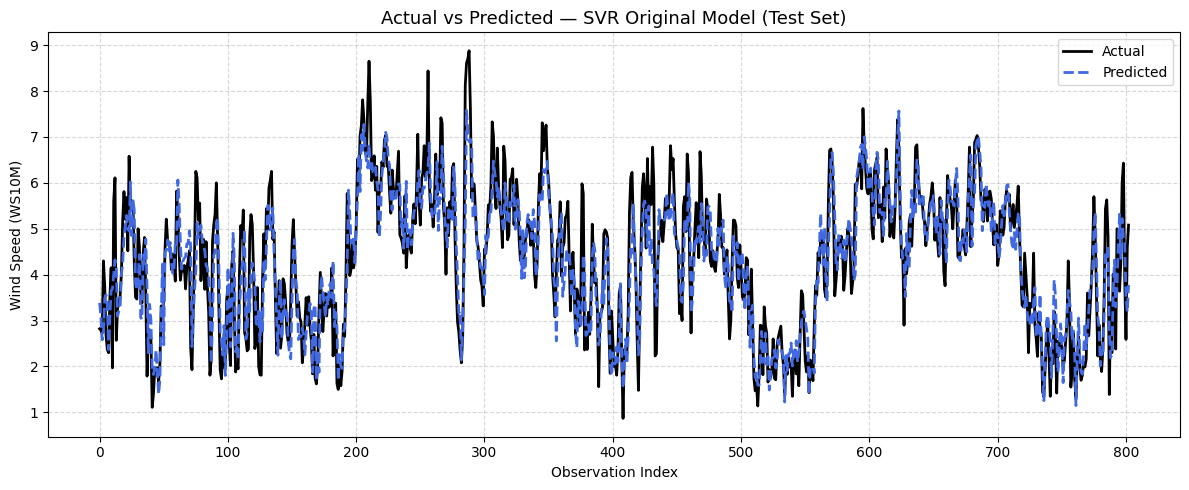

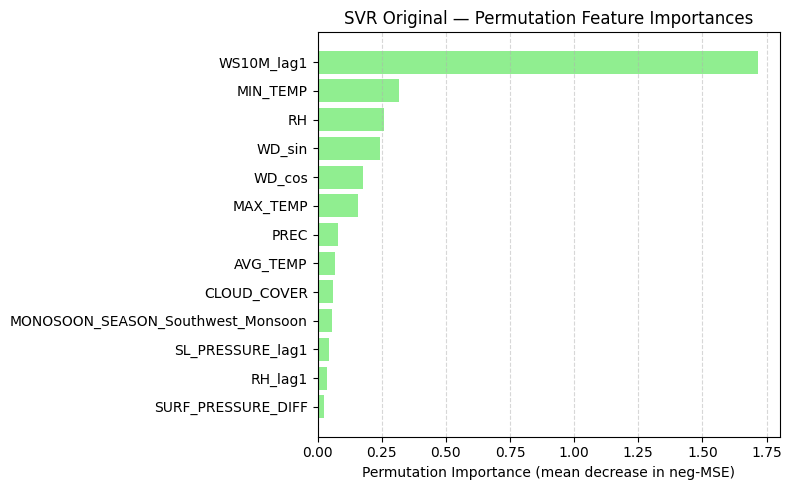

In [8]:
# ── SVR with default scikit-learn hyperparameters ──
# kernel='rbf', C=1.0, epsilon=0.1 (sklearn defaults)

svr_original = SVR(
    kernel='rbf',
    C=1.0,
    epsilon=0.1
)

# Fit on scaled training data
svr_original.fit(X_train_scaled, y_train)

# Predict on both splits
y_train_pred_orig = svr_original.predict(X_train_scaled)
y_test_pred_orig  = svr_original.predict(X_test_scaled)

# ── Performance Evaluation ──
print('=' * 50)
print('  SVR — ORIGINAL MODEL (Default Parameters)')
print('=' * 50)
print('\n[Training Set]')
tr_mse, tr_rmse, tr_mae, tr_mape, tr_r2 = evaluate_metrics(
    y_train, y_train_pred_orig, label='Train')
print('\n[Test Set]')
te_mse, te_rmse, te_mae, te_mape, te_r2 = evaluate_metrics(
    y_test, y_test_pred_orig, label='Test ')

# Store results for summary table
results_store['Original Model'] = {
    'Train RMSE': tr_rmse, 'Train MAE': tr_mae,
    'Train MAPE': tr_mape, 'Train R2' : tr_r2,
    'Test RMSE' : te_rmse, 'Test MAE' : te_mae,
    'Test MAPE' : te_mape, 'Test R2'  : te_r2
}

# ── Actual vs Predicted Plot ──
plot_actual_vs_predicted(
    y_test, y_test_pred_orig,
    title='Actual vs Predicted — SVR Original Model (Test Set)',
    color='royalblue'
)

# ── Permutation Feature Importance ──
# SVR does not expose feature_importances_; permutation importance is used instead.
imp_orig = plot_permutation_importance(
    svr_original, X_test_scaled, y_test,
    feature_names=X_test.columns.tolist(),
    title='SVR Original — Permutation Feature Importances',
    color='lightgreen'
)

# ─────────────────────────────────────────
# SECTION 7 — SVR: GRID SEARCH
#             (Exhaustive hyperparameter search)
# ─────────────────────────────────────────

Fitting 5 folds for each of 150 candidates, totalling 750 fits

Best Parameters (Grid Search):
{'C': 10, 'epsilon': 0.3, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV Score (neg-MSE): -0.4955

  SVR — GRID SEARCH (Optimised Parameters)

[Training Set]
Train MSE  : 0.4124
Train RMSE : 0.6422
Train MAE  : 0.4979
Train MAPE : 13.91%
Train R²   : 0.8363

[Test Set]
Test  MSE  : 0.5404
Test  RMSE : 0.7351
Test  MAE  : 0.5669
Test  MAPE : 15.40%
Test  R²   : 0.7759


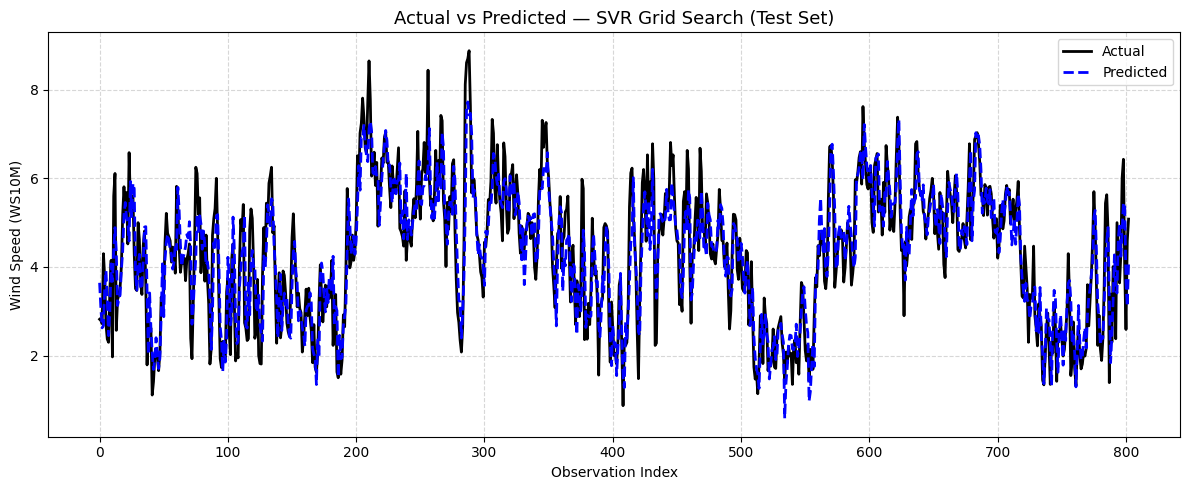

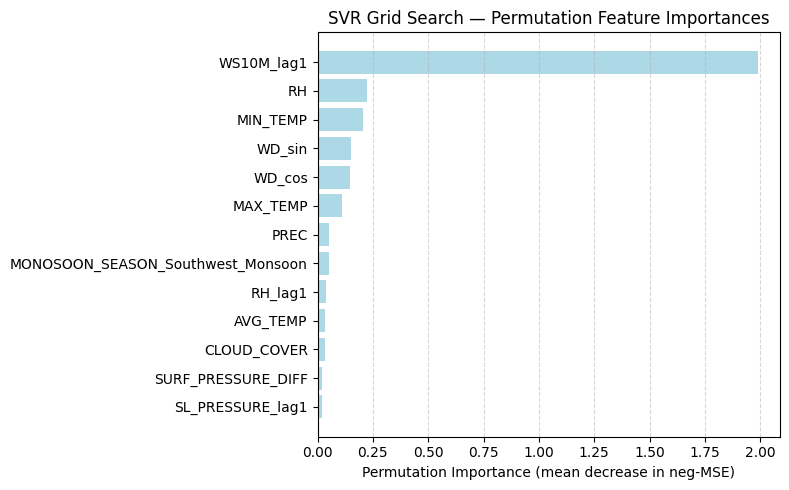

In [9]:
# ── Hyperparameter grid for exhaustive search ──
param_grid = {
    'C'      : [0.1, 1, 10, 50, 100],
    'epsilon': [0.01, 0.05, 0.1, 0.2, 0.3],
    'gamma'  : ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel' : ['rbf']
}

# ── TimeSeriesSplit: 5-fold CV applied to TRAINING DATA ONLY ──
# Ensures future observations never appear in a validation fold during tuning.
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

# Fit Grid Search on scaled training data only
grid_search.fit(X_train_scaled, y_train)

print('\nBest Parameters (Grid Search):')
print(grid_search.best_params_)
print(f'Best CV Score (neg-MSE): {grid_search.best_score_:.4f}')

# ── Refit best model on full training set ──
best_svr_grid = grid_search.best_estimator_

# Predict on both splits
y_train_pred_grid = best_svr_grid.predict(X_train_scaled)
y_test_pred_grid  = best_svr_grid.predict(X_test_scaled)

# ── Performance Evaluation ──
print('\n' + '=' * 50)
print('  SVR — GRID SEARCH (Optimised Parameters)')
print('=' * 50)
print('\n[Training Set]')
tr_mse, tr_rmse, tr_mae, tr_mape, tr_r2 = evaluate_metrics(
    y_train, y_train_pred_grid, label='Train')
print('\n[Test Set]')
te_mse, te_rmse, te_mae, te_mape, te_r2 = evaluate_metrics(
    y_test, y_test_pred_grid, label='Test ')

# Store results for summary table
results_store['Grid Search'] = {
    'Train RMSE': tr_rmse, 'Train MAE': tr_mae,
    'Train MAPE': tr_mape, 'Train R2' : tr_r2,
    'Test RMSE' : te_rmse, 'Test MAE' : te_mae,
    'Test MAPE' : te_mape, 'Test R2'  : te_r2
}

# ── Actual vs Predicted Plot ──
plot_actual_vs_predicted(
    y_test, y_test_pred_grid,
    title='Actual vs Predicted — SVR Grid Search (Test Set)',
    color='blue'
)

# ── Permutation Feature Importance ──
imp_grid = plot_permutation_importance(
    best_svr_grid, X_test_scaled, y_test,
    feature_names=X_test.columns.tolist(),
    title='SVR Grid Search — Permutation Feature Importances',
    color='lightblue'
)

# ─────────────────────────────────────────
# SECTION 8 — SVR: RANDOMIZED SEARCH
#             (Stochastic hyperparameter search)
# ─────────────────────────────────────────

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters (Randomized Search):
{'C': np.float64(11.675319046560459), 'epsilon': np.float64(0.26029999350392213), 'gamma': 0.01, 'kernel': 'rbf'}
Best CV Score (neg-MSE): -0.4952

  SVR — RANDOMIZED SEARCH (Optimised Parameters)

[Training Set]
Train MSE  : 0.4092
Train RMSE : 0.6397
Train MAE  : 0.4951
Train MAPE : 13.80%
Train R²   : 0.8376

[Test Set]
Test  MSE  : 0.5379
Test  RMSE : 0.7334
Test  MAE  : 0.5651
Test  MAPE : 15.33%
Test  R²   : 0.7769


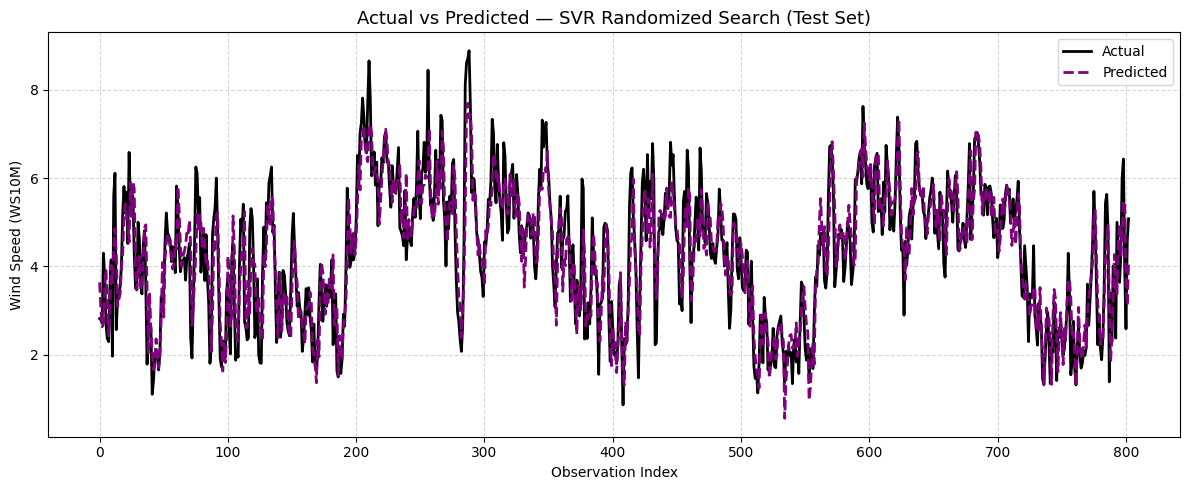

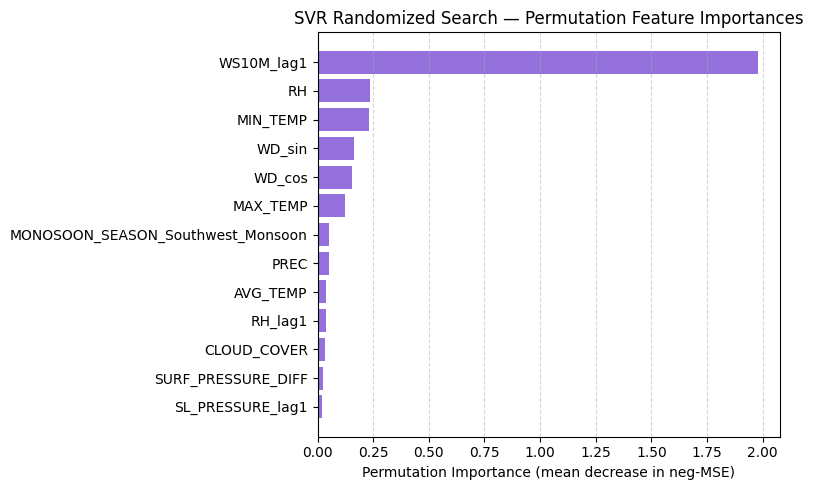

In [10]:
# ── Continuous and categorical distributions for random sampling ──
param_dist = {
    'C'      : uniform(loc=0.1, scale=99.9),     # Samples from U(0.1, 100)
    'epsilon': uniform(loc=0.01, scale=0.29),    # Samples from U(0.01, 0.30)
    'gamma'  : ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel' : ['rbf']
}

# ── TimeSeriesSplit: 5-fold CV applied to TRAINING DATA ONLY ──
tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=SVR(),
    param_distributions=param_dist,
    n_iter=50,                          # Number of random parameter combinations to try
    scoring='neg_mean_squared_error',
    cv=tscv,
    verbose=1,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

# Fit Randomized Search on scaled training data only
random_search.fit(X_train_scaled, y_train)

print('\nBest Parameters (Randomized Search):')
print(random_search.best_params_)
print(f'Best CV Score (neg-MSE): {random_search.best_score_:.4f}')

# ── Refit best model on full training set ──
best_svr_random = random_search.best_estimator_

# Predict on both splits
y_train_pred_random = best_svr_random.predict(X_train_scaled)
y_test_pred_random  = best_svr_random.predict(X_test_scaled)

# ── Performance Evaluation ──
print('\n' + '=' * 50)
print('  SVR — RANDOMIZED SEARCH (Optimised Parameters)')
print('=' * 50)
print('\n[Training Set]')
tr_mse, tr_rmse, tr_mae, tr_mape, tr_r2 = evaluate_metrics(
    y_train, y_train_pred_random, label='Train')
print('\n[Test Set]')
te_mse, te_rmse, te_mae, te_mape, te_r2 = evaluate_metrics(
    y_test, y_test_pred_random, label='Test ')

# Store results for summary table
results_store['Randomized Search'] = {
    'Train RMSE': tr_rmse, 'Train MAE': tr_mae,
    'Train MAPE': tr_mape, 'Train R2' : tr_r2,
    'Test RMSE' : te_rmse, 'Test MAE' : te_mae,
    'Test MAPE' : te_mape, 'Test R2'  : te_r2
}

# ── Actual vs Predicted Plot ──
plot_actual_vs_predicted(
    y_test, y_test_pred_random,
    title='Actual vs Predicted — SVR Randomized Search (Test Set)',
    color='purple'
)

# ── Permutation Feature Importance ──
imp_random = plot_permutation_importance(
    best_svr_random, X_test_scaled, y_test,
    feature_names=X_test.columns.tolist(),
    title='SVR Randomized Search — Permutation Feature Importances',
    color='mediumpurple'
)

# ─────────────────────────────────────────
# SECTION 9 — SVR: OPTUNA
#             (TPE-based Bayesian optimisation)
# ─────────────────────────────────────────


Best Trial:
  Value (mean CV RMSE): 0.7035
Best Parameters (Optuna):
{'C': 13.331484559997573, 'epsilon': 0.13518678547287313, 'gamma': 0.01}

  SVR — OPTUNA (Optimised Parameters)

[Training Set]
Train MSE  : 0.4082
Train RMSE : 0.6389
Train MAE  : 0.4898
Train MAPE : 13.59%
Train R²   : 0.8380

[Test Set]
Test  MSE  : 0.5437
Test  RMSE : 0.7374
Test  MAE  : 0.5690
Test  MAPE : 15.40%
Test  R²   : 0.7745


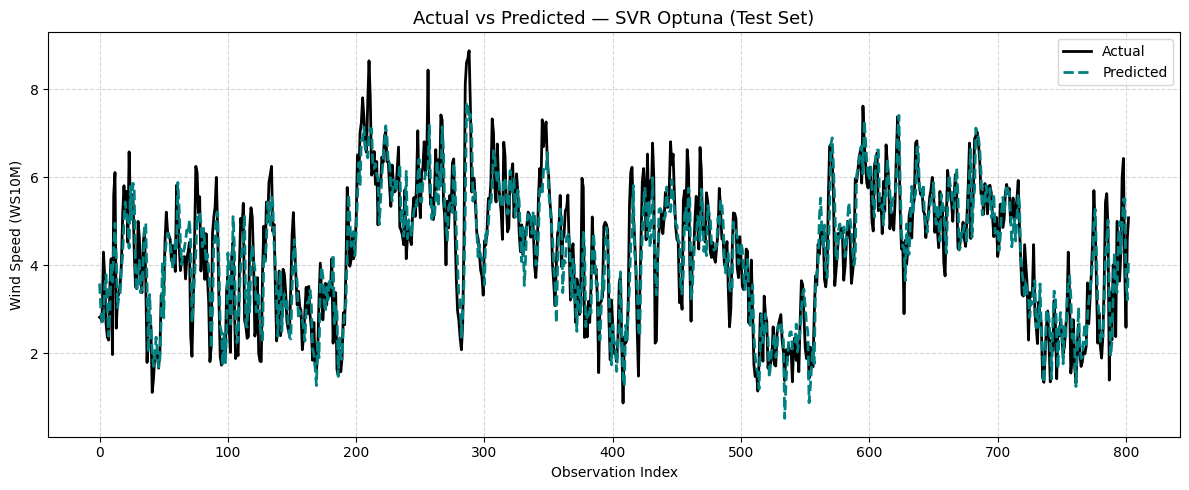

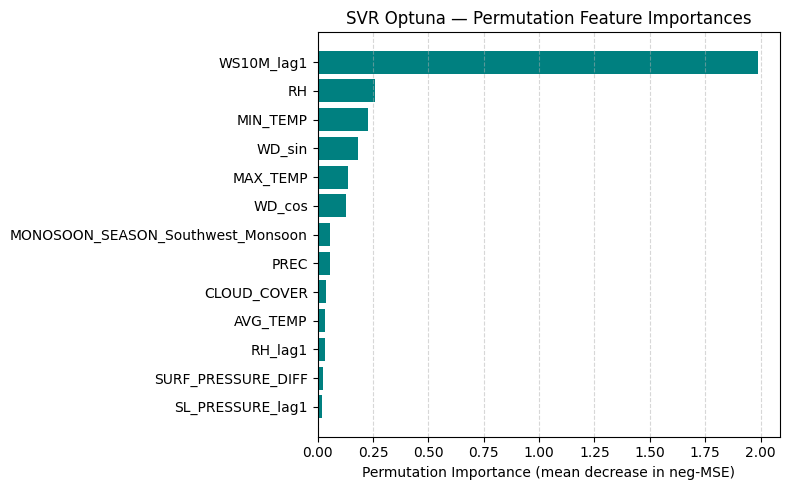

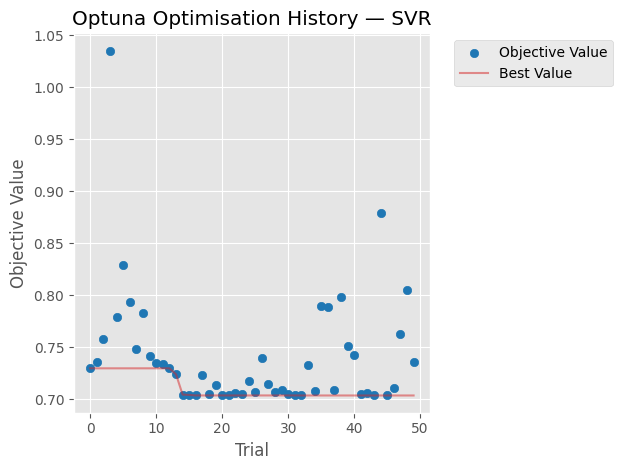

In [11]:
# ── Optuna objective function ──
# Performs TimeSeriesSplit CV on TRAINING DATA ONLY.
# Test data is never touched during optimisation (no data leakage).
def svr_objective(trial):
    params = {
        'C'      : trial.suggest_float('C',       0.1,   100.0, log=True),
        'epsilon': trial.suggest_float('epsilon', 0.01,  0.3),
        'gamma'  : trial.suggest_categorical('gamma', ['scale', 'auto', 0.001, 0.01, 0.1]),
        'kernel' : 'rbf'
    }

    tscv = TimeSeriesSplit(n_splits=5)
    fold_rmse = []

    for train_idx, val_idx in tscv.split(X_train_scaled):
        # Use the already-scaled numpy arrays — no re-fitting the scaler per fold
        X_fold_tr, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_fold_tr, y_fold_val = y_train.iloc[train_idx],   y_train.iloc[val_idx]

        model = SVR(**params)
        model.fit(X_fold_tr, y_fold_tr)
        preds = model.predict(X_fold_val)

        # Compute RMSE for this fold
        fold_rmse.append(np.sqrt(mean_squared_error(y_fold_val, preds)))

    return np.mean(fold_rmse)   # Minimise mean RMSE across folds


# ── Run Optuna study ──
# TPE (Tree-structured Parzen Estimator) sampler is Optuna's default and is
# more sample-efficient than the RandomSampler used in the original code.
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
study.optimize(svr_objective, n_trials=50, timeout=600)

print('\nBest Trial:')
print(f'  Value (mean CV RMSE): {study.best_trial.value:.4f}')
print('Best Parameters (Optuna):')
print(study.best_params)

# ── Refit SVR on full training set with best hyperparameters ──
best_svr_optuna = SVR(
    C       = study.best_params['C'],
    epsilon = study.best_params['epsilon'],
    gamma   = study.best_params['gamma'],
    kernel  = 'rbf'
)
best_svr_optuna.fit(X_train_scaled, y_train)

# Predict on both splits
y_train_pred_optuna = best_svr_optuna.predict(X_train_scaled)
y_test_pred_optuna  = best_svr_optuna.predict(X_test_scaled)

# ── Performance Evaluation ──
print('\n' + '=' * 50)
print('  SVR — OPTUNA (Optimised Parameters)')
print('=' * 50)
print('\n[Training Set]')
tr_mse, tr_rmse, tr_mae, tr_mape, tr_r2 = evaluate_metrics(
    y_train, y_train_pred_optuna, label='Train')
print('\n[Test Set]')
te_mse, te_rmse, te_mae, te_mape, te_r2 = evaluate_metrics(
    y_test, y_test_pred_optuna, label='Test ')

# Store results for summary table
results_store['Optuna'] = {
    'Train RMSE': tr_rmse, 'Train MAE': tr_mae,
    'Train MAPE': tr_mape, 'Train R2' : tr_r2,
    'Test RMSE' : te_rmse, 'Test MAE' : te_mae,
    'Test MAPE' : te_mape, 'Test R2'  : te_r2
}

# ── Actual vs Predicted Plot ──
plot_actual_vs_predicted(
    y_test, y_test_pred_optuna,
    title='Actual vs Predicted — SVR Optuna (Test Set)',
    color='teal'
)

# ── Permutation Feature Importance ──
imp_optuna = plot_permutation_importance(
    best_svr_optuna, X_test_scaled, y_test,
    feature_names=X_test.columns.tolist(),
    title='SVR Optuna — Permutation Feature Importances',
    color='teal'
)

# ── Optuna optimisation history plot ──
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title('Optuna Optimisation History — SVR')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# SECTION 10 — PERFORMANCE COMPARISON TABLE
#              All four methods side-by-side
# ─────────────────────────────────────────


  SVR PERFORMANCE SUMMARY — DATASET 1
  (80% Train / 20% Test  |  TimeSeriesSplit CV on train only)
+-------------------+--------------+-------------+--------------+------------+-------------+------------+-------------+-----------+
| Method            |   Train RMSE |   Train MAE |   Train MAPE |   Train R² |   Test RMSE |   Test MAE |   Test MAPE |   Test R² |
+===================+==============+=============+==============+============+=============+============+=============+===========+
| Original Model    |       0.6028 |      0.4463 |      12.0900 |     0.8558 |      0.7467 |     0.5724 |     15.1900 |    0.7688 |
+-------------------+--------------+-------------+--------------+------------+-------------+------------+-------------+-----------+
| Grid Search       |       0.6422 |      0.4979 |      13.9100 |     0.8363 |      0.7351 |     0.5669 |     15.4000 |    0.7759 |
+-------------------+--------------+-------------+--------------+------------+-------------+------------+--

,Method,Train RMSE,Train MAE,Train MAPE,Train R²,Test RMSE,Test MAE,Test MAPE,Test R²
0,Original Model,0.6028,0.4463,12.09,0.8558,0.7467,0.5724,15.19,0.7688
1,Grid Search,0.6422,0.4979,13.91,0.8363,0.7351,0.5669,15.40,0.7759
2,Randomized Search,0.6397,0.4951,13.80,0.8376,0.7334,0.5651,15.33,0.7769
3,Optuna,0.6389,0.4898,13.59,0.8380,0.7374,0.5690,15.40,0.7745


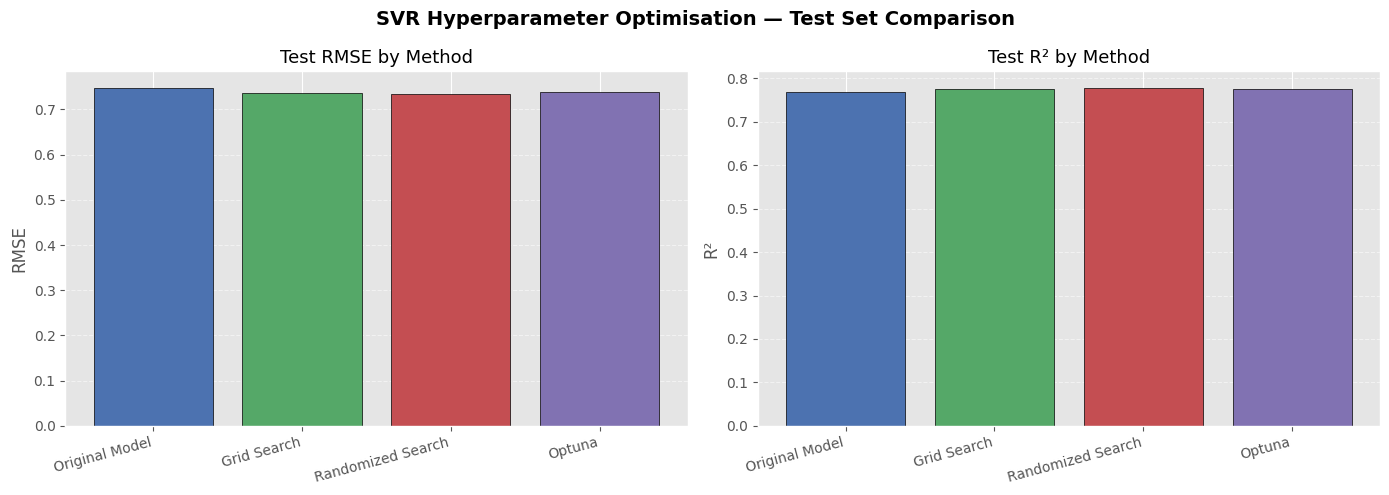

In [12]:
# ── Build the comparison DataFrame ──
methods = ['Original Model', 'Grid Search', 'Randomized Search', 'Optuna']

summary_data = []
for method in methods:
    r = results_store[method]
    summary_data.append({
        'Method'    : method,
        'Train RMSE': round(r['Train RMSE'], 4),
        'Train MAE' : round(r['Train MAE'],  4),
        'Train MAPE': round(r['Train MAPE'], 2),
        'Train R²'  : round(r['Train R2'],   4),
        'Test RMSE' : round(r['Test RMSE'],  4),
        'Test MAE'  : round(r['Test MAE'],   4),
        'Test MAPE' : round(r['Test MAPE'],  2),
        'Test R²'   : round(r['Test R2'],    4)
    })

summary_df = pd.DataFrame(summary_data)

# ── Pretty-print with tabulate ──
print('\n' + '=' * 80)
print('  SVR PERFORMANCE SUMMARY — DATASET 1')
print('  (80% Train / 20% Test  |  TimeSeriesSplit CV on train only)')
print('=' * 80)
print(tabulate(summary_df, headers='keys', tablefmt='grid',
               showindex=False, floatfmt='.4f'))

# ── Display as styled pandas table ──
display(summary_df.style
        .set_caption('SVR — Hyperparameter Optimisation Comparison (Dataset 1)')
        .highlight_min(subset=['Test RMSE','Test MAE','Test MAPE'], color='lightgreen')
        .highlight_max(subset=['Test R²'],                          color='lightgreen')
        .format({
            'Train RMSE':'{:.4f}','Train MAE':'{:.4f}',
            'Train MAPE':'{:.2f}','Train R²' :'{:.4f}',
            'Test RMSE' :'{:.4f}','Test MAE' :'{:.4f}',
            'Test MAPE' :'{:.2f}','Test R²'  :'{:.4f}'
        })
)

# ── Bar chart comparison (Test RMSE) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

axes[0].bar(summary_df['Method'], summary_df['Test RMSE'], color=colors, edgecolor='black')
axes[0].set_title('Test RMSE by Method', fontsize=13)
axes[0].set_ylabel('RMSE')
axes[0].set_xticklabels(summary_df['Method'], rotation=15, ha='right')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].bar(summary_df['Method'], summary_df['Test R²'], color=colors, edgecolor='black')
axes[1].set_title('Test R² by Method', fontsize=13)
axes[1].set_ylabel('R²')
axes[1].set_xticklabels(summary_df['Method'], rotation=15, ha='right')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('SVR Hyperparameter Optimisation — Test Set Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()